# Task 2: Data Preprocessing & Augmentation

This notebook is focused on applying geometric and photometric transformations to expand the dataset and improve model generalization.

**Justification for Augmentation in Radar/Traffic Detection**:
1. **Geometric Transforms** (Flipping, Rotation, Cropping, Shearing): Replicates variations in camera angles, vehicles moving in different directions, and occlusions/cropping at the edges of the camera frame.
2. **Photometric Transforms** (Brightness, Grayscale, Channel Dropout): Mimics day/night cycles, diverse weather conditions, shadows, and varying sensor qualities.

In [2]:
# 1. Import Required Libraries
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A

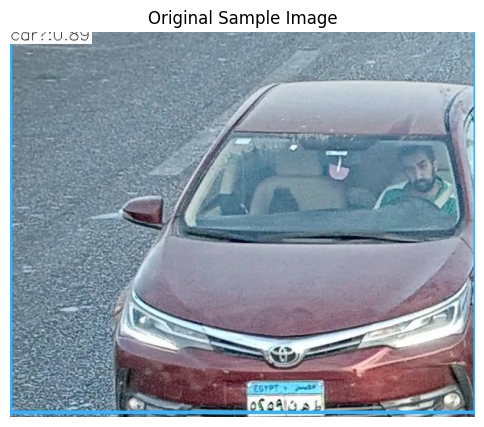

In [12]:
# 2. Load Original Dataset Sample
train_images_dir = r"Dataset_Split\train"
all_images = glob.glob(os.path.join(train_images_dir, '**', '*.jpg'), recursive=True)


random.seed(30)
sample_img_path = random.choice(all_images)
    
# Load image using OpenCV (BGR to RGB)
image = cv2.imread(sample_img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original Sample Image")
plt.axis("off")
plt.show()

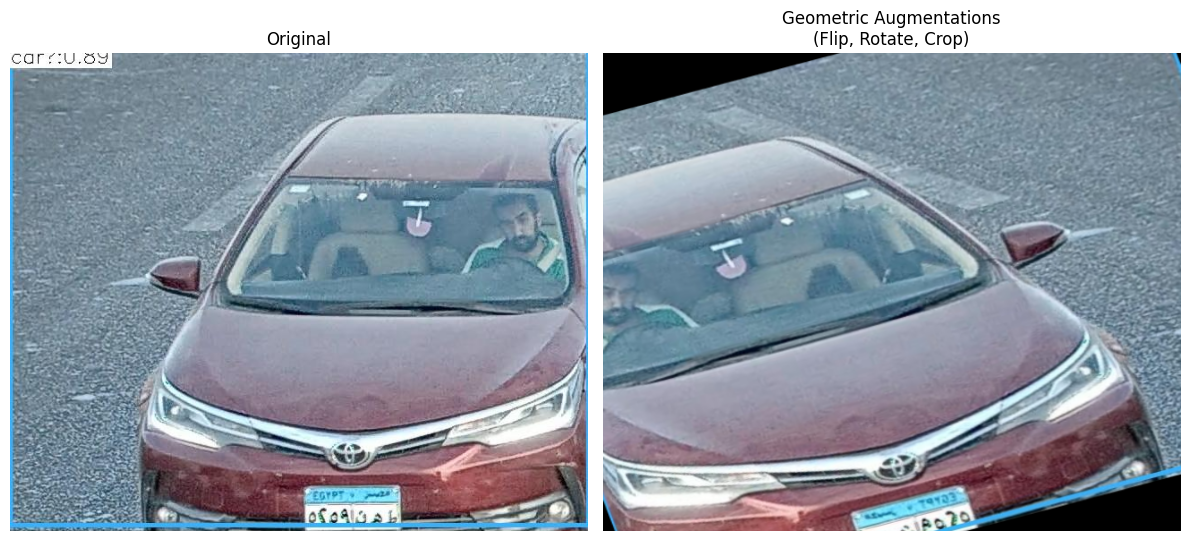

In [10]:
# 3. Implement Geometric Transformations
# Applying Horizontal Flip, Rotation, and Random Crop

geom_transform = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=20, p=1.0, border_mode=cv2.BORDER_CONSTANT),
    A.RandomResizedCrop(
        size=(image.shape[0], image.shape[1]),
        scale=(0.8, 0.8),
        ratio=(1.0, 1.0),
        p=1.0
    )
])

geom_augmented = geom_transform(image=image)['image']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(geom_augmented)
axes[1].set_title("Geometric Augmentations\n(Flip, Rotate, Crop)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

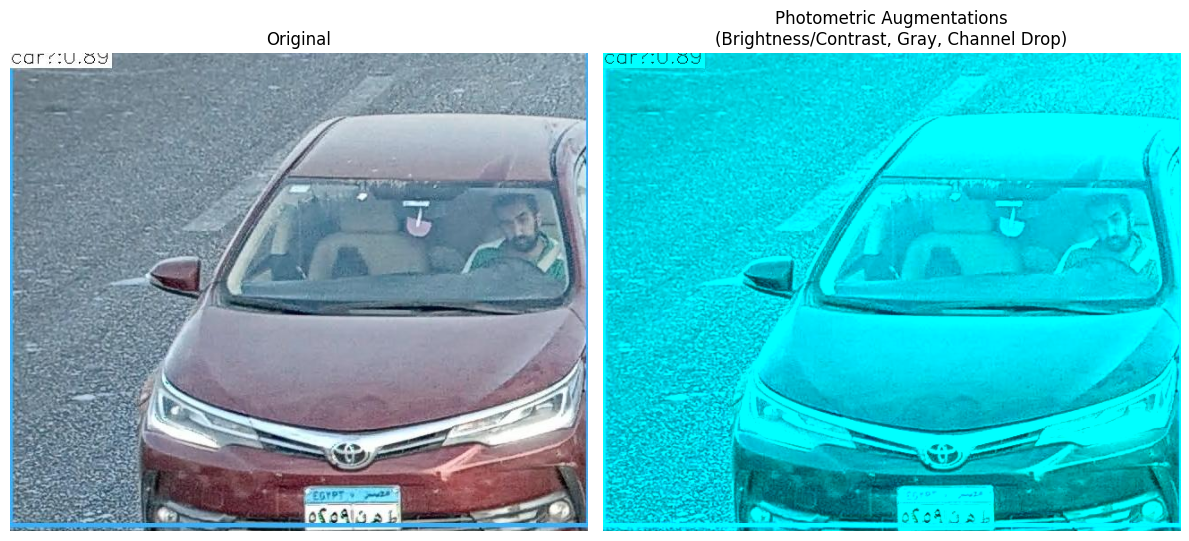

In [9]:
# 4. Implement Photometric Transformations
# Applying Brightness/Contrast adjust, Grayscale, and Channel Dropout

photo_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
    A.ToGray(p=0.5), # 50% chance to become grayscale
    A.ChannelDropout(p=0.5) 
])

photo_augmented = photo_transform(image=image)['image']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(photo_augmented)
axes[1].set_title("Photometric Augmentations\n(Brightness/Contrast, Gray, Channel Drop)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 6. Calculate Effective Dataset Size

### How Augmentation Affects the Effective Dataset Size
By applying dynamic data augmentation during the training pipeline via a data loader (like PyTorch's DataLoader), we perform the transformations *on-the-fly*. Because random parameters are picked dynamically (e.g. brightness `±0.3`, flip `p=0.5`, rotation `±20°`), the exact same original training image is seen slightly differently every single epoch!

If we have `N` static images in the training set and train for `E` epochs using random continuous augmentations, the model effectively sees `N * E` unique variations of the dataset. This dramatically increases variability and resistance to overfitting, simulating an infinitely expanding dataset without collecting any new physical data.